# Experiment 3: data parsing and analyses

In [1]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import os
import pickle
import glob 
import itertools
import re
from statannotations.Annotator import Annotator
import json
from scipy.stats import ttest_rel, wilcoxon, ttest_ind, ranksums
from statsmodels.stats.proportion import proportions_ztest
from collections import Counter
import ast
from collections import deque
import matplotlib.cm as cm
from matplotlib import gridspec
import matplotlib.patches as patches
import math
import string
from copy import deepcopy
import pickle
import heapq
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from patsy import dmatrix, build_design_matrices  # <- key import
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from typing import Any, Optional, Tuple
from scipy import stats
from pathlib import Path



figpath = os.path.join("fig")
fitspath = os.path.join("modelfits")
data_savepath = os.path.join("data")
datapath = os.path.join("..","experiment","data", "exp3")

exp_conds = [0,1] # 0 is easy, 1 is hard (either colorhover or visualsearch)


In [2]:
from __future__ import annotations

import json
import ast
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd


# =========================
# Parsing helpers
# =========================

def parse_maybe_json(x: Any) -> Any:
    """
    Parse a CSV cell that may contain:
    - JSON string
    - Python literal string
    - already-parsed object
    - NaN / missing
    """
    if pd.isna(x):
        return None

    if isinstance(x, (dict, list, tuple, int, float, bool)):
        return x

    if not isinstance(x, str):
        return x

    s = x.strip()
    if s == "":
        return None

    # Try JSON first
    try:
        return json.loads(s)
    except Exception:
        pass

    # Fall back to Python literal
    try:
        return ast.literal_eval(s)
    except Exception:
        return s



def parse_info_first_reveal_order(x: Any) -> Any:
    """
    Special parser for info_first_reveal_order.

    This column is saved as a Python-dict-like string containing bare nan:

        "{'nodes': {'StartTown': nan, ...}, 'edges': {...}}"

    ast.literal_eval cannot parse bare nan, so we replace standalone nan
    with float('nan') and evaluate in a restricted namespace.
    """
    if isinstance(x, dict):
        return x

    if x is None:
        return np.nan

    if isinstance(x, float) and pd.isna(x):
        return np.nan

    if not isinstance(x, str):
        return x

    s = x.strip()

    if s == "" or s.lower() in {"nan", "none", "null", "<na>"}:
        return np.nan

    if not s.startswith("{"):
        return x

    # Replace only standalone nan tokens, not substrings.
    s = re.sub(r"\bnan\b", "float('nan')", s)

    try:
        return eval(
            s,
            {"__builtins__": {}},
            {"float": float}
        )
    except Exception:
        return x


def coerce_bool(x: Any) -> Any:
    """
    Convert common yes/no/true/false variants to bool.
    Return np.nan for missing.
    """
    if pd.isna(x):
        return np.nan
    if isinstance(x, bool):
        return x
    if isinstance(x, (int, np.integer)):
        return bool(x)
    if isinstance(x, float):
        if np.isnan(x):
            return np.nan
        return bool(x)

    s = str(x).strip().lower()
    if s in {"true", "t", "1", "yes", "y"}:
        return True
    if s in {"false", "f", "0", "no", "n"}:
        return False
    return np.nan



# =========================
# Path / edge helpers
# =========================

def parse_path_string_to_nodes(path_str: Any) -> List[str]:
    if pd.isna(path_str) or path_str is None:
        return []
    s = str(path_str).strip()
    if s == "":
        return []
    if "→" in s:
        return [x.strip() for x in s.split("→")]
    if "->" in s:
        return [x.strip() for x in s.split("->")]
    return [s]



def path_to_expected_label_sequence(path_str: Any) -> List[Tuple[str, str]]:
    """
    Returns sequence like:
    [('node','K'), ('edge','K--E'), ('node','E'), ('edge','E--GoalCity'), ('node','GoalCity')]

    This matches the example in the prompt, i.e., excludes StartTown.
    """
    nodes = parse_path_string_to_nodes(path_str)
    if len(nodes) < 2:
        return []

    seq = []
    for i in range(1, len(nodes)): # skip i=0, which is "node":StartCity
        current_node = nodes[i]
        prev_node = nodes[i - 1]
        seq.append(("edge", canonical_edge_key(prev_node, current_node)))
        seq.append(("node", current_node))
    return seq


def path_to_label_set(path_str: Any) -> Dict[str, set]:
    nodes = parse_path_string_to_nodes(path_str)
    out_nodes = set(nodes)
    out_edges = set()
    for a, b in zip(nodes[:-1], nodes[1:]):
        out_edges.add(canonical_edge_key(a, b))
    return {"nodes": out_nodes, "edges": out_edges}


def union_cached_label_set(cached_solution_1: Any, cached_solution_2: Any) -> Dict[str, set]:
    s1 = path_to_label_set(cached_solution_1)
    s2 = path_to_label_set(cached_solution_2)
    return {
        "nodes": set(s1["nodes"]) | set(s2["nodes"]),
        "edges": set(s1["edges"]) | set(s2["edges"]),
    }

EDGE_SEPARATORS = ["--", "->", "→"]


def split_edge_label(edge_label: Any) -> Optional[Tuple[str, str]]:
    """
    Parse an undirected edge label written as:
      A--B
      A->B
      A→B

    Returns
    -------
    (a, b) if parsing succeeds, else None
    """
    if edge_label is None or pd.isna(edge_label):
        return None

    s = str(edge_label).strip()
    if s == "":
        return None

    for sep in EDGE_SEPARATORS:
        if sep in s:
            parts = s.split(sep)
            if len(parts) == 2:
                a, b = parts[0].strip(), parts[1].strip()
                if a != "" and b != "":
                    return a, b

    return None


def canonicalize_edge_label(edge_label: Any) -> Any:
    """
    Make undirected edge labels order-invariant across supported separators.

    Examples
    --------
    'DEF--ABC' -> 'ABC--DEF'
    'DEF->ABC' -> 'ABC--DEF'
    'DEF→ABC'  -> 'ABC--DEF'

    Returns the original stripped string if it cannot be parsed as a 2-endpoint edge.
    """
    parsed = split_edge_label(edge_label)
    if parsed is None:
        if edge_label is None or pd.isna(edge_label):
            return edge_label
        return str(edge_label).strip()

    a, b = parsed
    a, b = sorted([a, b])
    return f"{a}--{b}"


def canonical_edge_key(a: str, b: str) -> str:
    return canonicalize_edge_label(f"{a}--{b}")


def parse_info_reveal_seconds(x: Any) -> Dict[str, Dict[str, float]]:
    parsed = parse_maybe_json(x)
    empty = {"nodes": {}, "edges": {}}

    if parsed is None or not isinstance(parsed, dict):
        return empty

    nodes_raw = parsed.get("nodes", {})
    edges_raw = parsed.get("edges", {})

    if not isinstance(nodes_raw, dict):
        nodes_raw = {}
    if not isinstance(edges_raw, dict):
        edges_raw = {}

    nodes = {}
    for k, v in nodes_raw.items():
        try:
            nodes[str(k)] = float(v)
        except Exception:
            pass

    edges = {}
    for k, v in edges_raw.items():
        try:
            edges[canonicalize_edge_label(k)] = float(v)
        except Exception:
            pass

    return {"nodes": nodes, "edges": edges}


def extract_first_select_order_from_event_log(event_log: Any) -> Dict[str, Dict[str, float]]:
    """
    Use event_log to determine the order in which each edge
    was FIRST selected.

    Returns nested dict:
    {
      "nodes": {"A": 1, "B": 2, ...},
      "edges": {"A--B": 1, ...}
    }

    Only labels that were ever shown are included here.
    Missing labels can later be filled with np.nan using the full label set
    from info_reveal_seconds.
    """
    parsed = parse_maybe_json(event_log)
    if not isinstance(parsed, list):
        return {"nodes": {}, "edges": {}}

    node_order = {}
    edge_order = {}
    counter = 1

    for ev in parsed:
        if not isinstance(ev, dict):
            continue
        if ev.get("type") != "toggle_edge_select":
            continue
        edge_id = ev.get("edge_id")
        if edge_id is not None and edge_id not in edge_order:
            edge_order[edge_id] = counter
            counter += 1

    return {"edges": edge_order}

def extract_last_select_order_from_event_log(event_log: Any) -> Dict[str, Dict[str, float]]:
    """
    Use event_log to determine the order in which each edge
    was LAST selected.

    Returns:
    {
      "edges": {"A--B": 1, ...}
    }
    """
    parsed = parse_maybe_json(event_log)
    if not isinstance(parsed, list):
        return {"nodes": {}, "edges": {}}

    last_occurrence = {}

    for idx, ev in enumerate(parsed):
        if not isinstance(ev, dict):
            continue
        if ev.get("type") != "toggle_edge_select":
            continue

        edge_id = ev.get("edge_id")
        if edge_id is not None:
            edge_id = canonicalize_edge_label(edge_id)
            last_occurrence[edge_id] = idx

    sorted_edges = sorted(last_occurrence.items(), key=lambda x: x[1])
    edge_order = {edge_id: i + 1 for i, (edge_id, _) in enumerate(sorted_edges)}

    return {"nodes": {}, "edges": edge_order}


def get_order_val(order_dict: Dict[str, Dict[str, float]], kind: str, label: str) -> float:
    if not isinstance(order_dict, dict):
        return np.nan

    if kind == "node":
        return order_dict.get("nodes", {}).get(label, np.nan)

    if kind == "edge":
        return order_dict.get("edges", {}).get(canonicalize_edge_label(label), np.nan)

    return np.nan


def extract_first_reveal_order_from_event_log(event_log: Any) -> Dict[str, Dict[str, float]]:
    """
    Use event_log to determine the order in which each node/edge label
    was FIRST revealed.

    Returns nested dict:
    {
      "nodes": {"A": 1, "B": 3, ...},
      "edges": {"A--B": 2, ...}
    }

    Only labels that were ever shown are included here.
    Missing labels can later be filled with np.nan using the full label set
    from info_reveal_seconds.
    """
    parsed = parse_maybe_json(event_log)
    if not isinstance(parsed, list):
        return {"nodes": {}, "edges": {}}

    node_order = {}
    edge_order = {}
    counter = 1

    for ev in parsed:
        if not isinstance(ev, dict):
            continue
        if ev.get("type") != "label_shown":
            continue

        kind = ev.get("kind")
        if kind == "node":
            node_id = ev.get("node_id")
            if node_id is not None:
                node_id = str(node_id)
                if node_id not in node_order:
                    node_order[node_id] = counter
                    counter += 1

        elif kind == "edge":
            edge_id = ev.get("edge_id")
            if edge_id is not None:
                edge_id = canonicalize_edge_label(edge_id)
                if edge_id not in edge_order:
                    edge_order[edge_id] = counter
                    counter += 1

    return {"nodes": node_order, "edges": edge_order}


def build_reveal_boolean_dict(info_reveal_seconds: Dict[str, Dict[str, float]]) -> Dict[str, Dict[str, bool]]:
    return {
        "nodes": {k: (v > 0) for k, v in info_reveal_seconds.get("nodes", {}).items()},
        "edges": {k: (v > 0) for k, v in info_reveal_seconds.get("edges", {}).items()},
    }


def build_reveal_order_full_dict(
    info_reveal_seconds: Dict[str, Dict[str, float]],
    first_order_partial: Dict[str, Dict[str, float]]
) -> Dict[str, Dict[str, float]]:
    """
    Fill in np.nan for labels that were never revealed.
    """
    out = {"nodes": {}, "edges": {}}

    all_nodes = info_reveal_seconds.get("nodes", {})
    all_edges = info_reveal_seconds.get("edges", {})

    partial_nodes = first_order_partial.get("nodes", {})
    partial_edges = first_order_partial.get("edges", {})

    for k in all_nodes:
        out["nodes"][k] = partial_nodes.get(k, np.nan)

    for k in all_edges:
        out["edges"][k] = partial_edges.get(k, np.nan)

    return out


def choose_cached_solution_with_lower_loss(
    submitted_path: Any,
    cached_solution_1: Any,
    cached_solution_2: Any,
    cached_solution_1_loss: Any,
    cached_solution_2_loss: Any,
) -> Any:
    """
    Returns:
    - 1 if subject chose the lower-loss cached solution
    - 0 if subject chose a cached solution but it was the higher-loss one
    - np.nan if subject did not choose either cached solution
    - np.nan if losses are missing or tied
    """
    if pd.isna(submitted_path):
        return np.nan

    chose_1 = submitted_path == cached_solution_1
    chose_2 = submitted_path == cached_solution_2

    if not (chose_1 or chose_2):
        return np.nan

    if pd.isna(cached_solution_1_loss) or pd.isna(cached_solution_2_loss):
        return np.nan

    if cached_solution_1_loss == cached_solution_2_loss:
        return np.nan

    lower_is_1 = cached_solution_1_loss < cached_solution_2_loss
    if chose_1:
        return int(lower_is_1)
    if chose_2:
        return int(not lower_is_1)

    return np.nan


# Only run the code block below if you collected new data files

In [3]:

# # =========================
# # Row extractors
# # =========================

# SUBJECT_LEVEL_LASTROW_COLS = [
#     "gender",
#     "age",
#     "color_blindness",
#     "gen_ai",
#     "summary",
#     "strategy",
#     "comment",
#     "screen",
#     "num_successful_trials",
#     "bonus_final_unclipped",
#     "bonus_final",
# ]
# SUBJECT_LEVEL_FIRSTROW_COLS = ["os","browser"]

# def get_last_row_subject_info(df_raw: pd.DataFrame) -> dict:
#     if df_raw.empty:
#         return {col: np.nan for col in SUBJECT_LEVEL_LASTROW_COLS} | {col: np.nan for col in SUBJECT_LEVEL_FIRSTROW_COLS}
#     first_row = df_raw.iloc[0]
#     last_row = df_raw.iloc[-1]
#     return {col: last_row[col] if col in df_raw.columns else np.nan for col in SUBJECT_LEVEL_LASTROW_COLS} | {col: first_row[col] if col in df_raw.columns else np.nan for col in SUBJECT_LEVEL_FIRSTROW_COLS}

# def extract_test_rows(df_raw: pd.DataFrame, mturk_id: str, subject_idx: int) -> pd.DataFrame:
#     test_df = df_raw.loc[df_raw["phase"] == "test"].copy()
#     subject_info = get_last_row_subject_info(df_raw)

#     if test_df.empty:
#         return pd.DataFrame()

#     rows = []
#     for _, row in test_df.iterrows():
#         info_secs = parse_info_reveal_seconds(row.get("info_reveal_seconds"))
#         first_order_partial = extract_first_reveal_order_from_event_log(row.get("event_log"))
#         info_revealed_bool = build_reveal_boolean_dict(info_secs)
#         info_first_reveal_order = build_reveal_order_full_dict(info_secs, first_order_partial)
#         last_select_order = extract_last_select_order_from_event_log(row.get("event_log"))

#         submitted_path = row.get("submitted_path_string")
#         cached_1 = row.get("cached_solution_1")
#         cached_2 = row.get("cached_solution_2")
#         timeout = row.get("timed_out")

#         submitted_equals_cached_1 = submitted_path == cached_1 if pd.notna(submitted_path) and pd.notna(cached_1) else False
#         submitted_equals_cached_2 = submitted_path == cached_2 if pd.notna(submitted_path) and pd.notna(cached_2) else False
#         submitted_equals_any_cached = submitted_equals_cached_1 or submitted_equals_cached_2

#         chose_lower_loss_cached = choose_cached_solution_with_lower_loss(
#             submitted_path=submitted_path,
#             cached_solution_1=cached_1,
#             cached_solution_2=cached_2,
#             cached_solution_1_loss=row.get("cached_solution_1_loss"),
#             cached_solution_2_loss=row.get("cached_solution_2_loss"),
#         )
#         rows.append({
#             "mturkID": mturk_id,
#             "subject_idx": subject_idx,
#             "phase": "test",

#             # indices
#             "sampled_test_order": row.get("sampled_test_order"),
#             "problem_idx": row.get("problem_idx"),
#             "rt": row["rt"] if "rt" in row else np.nan,

#             # submitted vs cached
#             "submitted_path_string": submitted_path,
#             "cached_solution_1": cached_1,
#             "cached_solution_2": cached_2,
#             "submitted_equals_cached_solution_1": submitted_equals_cached_1,
#             "submitted_equals_cached_solution_2": submitted_equals_cached_2,
#             "submitted_equals_any_cached_solution": submitted_equals_any_cached,

#             # reveal data
#             "info_reveal_seconds": info_secs,
#             "info_revealed_bool": info_revealed_bool,
#             "info_first_reveal_order": info_first_reveal_order,
#             "last_select_order": last_select_order,
#             "event_log": row.get("event_log"),
            
#             #Invalid submissions that were blocked:
#             "invalid_submit_count_before_success": row.get("invalid_submit_count_before_success"),
#             "invalid_submit_count_nonzero": int(1-row.get("invalid_submit_count_never")),
#             "timeout": int(row.get("timed_out")),

#             # losses
#             "loss": row.get("loss"),
#             "cached_solution_1_loss": row.get("cached_solution_1_loss"),
#             "cached_solution_2_loss": row.get("cached_solution_2_loss"),
#             "cached_solution_best_loss": min(row.get("cached_solution_1_loss"), row.get("cached_solution_2_loss")),
#             "chose_lower_loss_cached_solution": chose_lower_loss_cached,

#             # optimal path
#             "trial_best_loss": row.get("trial_best_loss"),
#             "trial_best_path": row.get("trial_best_path"),
#             **subject_info
#         })

#     out = pd.DataFrame(rows)
#     #out['cached_solution_best_loss'] = out[['cached_solution_1_loss', 'cached_solution_2_loss']].min(axis=1)
#     out = out.sort_values(["subject_idx", "sampled_test_order"], kind="stable").reset_index(drop=True)
#     return out


# def extract_recall_rows(df_raw: pd.DataFrame, mturk_id: str, subject_idx: int) -> pd.DataFrame:
#     recall_df = df_raw.loc[df_raw["phase"] == "recall_probe"].copy()

#     if recall_df.empty:
#         return pd.DataFrame()

#     rows = []
#     for _, row in recall_df.iterrows():
#         # Some saved files may have the *_bool / *_correct columns empty,
#         # while the alternative columns are filled.
#         response_bool = row.get("recall_probe_response_bool")
#         if pd.isna(response_bool):
#             response_bool = row.get("recall_probe_response_asbool")
#         response_bool = coerce_bool(response_bool)

#         response_correct = row.get("recall_probe_response_correct")
#         if pd.isna(response_correct):
#             response_correct = row.get("recall_probe_response_iscorrect")
#         response_correct = coerce_bool(response_correct)

#         true_edge_exists = coerce_bool(row.get("recall_probe_true_edge_exists"))

#         rows.append({
#             "mturkID": mturk_id,
#             "subject_idx": subject_idx,
#             "phase": "recall_probe",
#             "rt": row["rt"] if "rt" in row else np.nan,

#             # match back to test trial
#             "sampled_test_order": row.get("sampled_test_order"),

#             # recall probe info
#             "recall_probe_family": row.get("recall_probe_family"),
#             "recall_probe_analysis_class": row.get("recall_probe_analysis_class"),
#             "recall_probe_response_bool": response_bool,
#             "recall_probe_true_edge_exists": true_edge_exists,
#             "recall_probe_response_correct": response_correct,
#         })

#     out = pd.DataFrame(rows)
#     out = out.sort_values(["subject_idx", "sampled_test_order"], kind="stable").reset_index(drop=True)
#     return out


# # =========================
# # Main loader
# # =========================

# def load_covid_itinerary_folder(data_dir: str | Path) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
#     """
#     Read all CSVs in a folder and return:
#     - combined_long_df: test and recall stacked together
#     - test_df
#     - recall_df
#     """
#     data_dir = Path(data_dir)
#     csv_files = sorted(data_dir.glob("*.csv"))

#     if not csv_files:
#         raise FileNotFoundError(f"No CSV files found in: {data_dir}")

#     test_dfs = []
#     recall_dfs = []

#     for subject_idx, csv_path in enumerate(csv_files):
#         mturk_id = csv_path.stem  # filename minus .csv
#         df_raw = pd.read_csv(csv_path, encoding="utf-8")
#         # Compute RT as difference in cumulative time (in seconds)
#         df_raw["rt"] = df_raw["time_elapsed"].diff() / 1000
#         # First row has no previous row
#         df_raw.loc[df_raw.index[0], "rt"] = np.nan
#         df_raw['phase'] = pd.Categorical(df_raw['phase'], categories=['test', 'recall_probe'], ordered=True)


#         # Extract requested trial types
#         test_df = extract_test_rows(df_raw, mturk_id=mturk_id, subject_idx=subject_idx)
#         recall_df = extract_recall_rows(df_raw, mturk_id=mturk_id, subject_idx=subject_idx)

#         if not test_df.empty:
#             test_dfs.append(test_df)
#         if not recall_df.empty:
#             recall_dfs.append(recall_df)

#     test_df = pd.concat(test_dfs, ignore_index=True) if test_dfs else pd.DataFrame()
#     recall_df = pd.concat(recall_dfs, ignore_index=True) if recall_dfs else pd.DataFrame()

#     combined_long_df = pd.concat([test_df, recall_df], ignore_index=True, sort=False)
#     combined_long_df['phase'] = pd.Categorical(combined_long_df['phase'], categories=['test', 'recall_probe'], ordered=True)
#     combined_long_df = combined_long_df.sort_values(
#         ["subject_idx", "sampled_test_order","phase",],
#         kind="stable"
#     ).reset_index(drop=True)

#     return combined_long_df, test_df, recall_df


# # =========================
# # Example usage
# # =========================

# if __name__ == "__main__":
#     data_folder = datapath

#     combined_df, test_df, recall_df = load_covid_itinerary_folder(data_folder)
#     test_df["info_reveal_seconds"] = test_df["info_reveal_seconds"].apply(parse_info_reveal_seconds)

#     print("Combined shape:", combined_df.shape)
#     print("Test shape:", test_df.shape)
#     print("Recall shape:", recall_df.shape)

#     print("\nTest columns:")
#     print(test_df.columns.tolist())

#     print("\nRecall columns:")
#     print(recall_df.columns.tolist())

#     # Optional saves
#     # combined_df.to_pickle("covid_itinerary_combined.pkl")
#     # test_df.to_pickle("covid_itinerary_test.pkl")
#     # recall_df.to_pickle("covid_itinerary_recall.pkl")

#     # CSV output:
#     # combined_df.to_csv("exp3_pilot_data.csv", index=False, encoding="utf-8-sig")
#     # test_df.to_csv("covid_itinerary_test.csv", index=False)
#     # recall_df.to_csv("covid_itinerary_recall.csv", index=False)
    
# # Save bonus information of each subject
# demographics_df = (
#     test_df[
#         ["mturkID", "subject_idx"] + SUBJECT_LEVEL_FIRSTROW_COLS + SUBJECT_LEVEL_LASTROW_COLS
#     ]
#     .drop_duplicates(subset=["subject_idx"])
# )

# demographics_df['gender'].value_counts()
# #demographics_df[["mturkID","bonus_final"]].to_csv("bonus.csv", header=False, index=False)
# test_df_temp = test_df.drop(columns='mturkID')
# test_df_temp.to_csv(os.path.join("data","exp3_data_noexclusion_raw.csv"), index=False, header=True)

In [4]:
# # Exclude subjects:
# # 1) Self-report using LLMs
# llm_self_report_excl = set(demographics_df[demographics_df["gen_ai"]!="No"]["mturkID"]) # set()
# if("exp3_pilot1" in datapath):
#     llm_self_report_excl = set()
# # 2) Failed the white text LLM checks
# white_txt_summary = set(demographics_df[demographics_df["summary"].str.contains('tiramisu', case=False, na=False)]["mturkID"])
# white_txt_strategy = set(demographics_df[demographics_df["strategy"].str.contains('bucolic', case=False, na=False)]["mturkID"])

# # 3) Did not submit within time limit for more than half of the trials (>7)
# num_timeout_trials = test_df['submitted_path_string'].isna().groupby(test_df['mturkID']).sum()>7
# toomany_timeouts = set(num_timeout_trials[num_timeout_trials].index)

# exclude_subjs = list(llm_self_report_excl | white_txt_summary | white_txt_strategy | toomany_timeouts)
# print(exclude_subjs)
# combined_df = combined_df[~combined_df['mturkID'].isin(exclude_subjs)]
# test_df = test_df[~test_df['mturkID'].isin(exclude_subjs)]
# if(not recall_df.empty):
#     recall_df = recall_df[~recall_df['mturkID'].isin(exclude_subjs)]
# demographics_df = demographics_df[~demographics_df['mturkID'].isin(exclude_subjs)]

# # For timeouts, replace them with nans
# test_df["loss"] = test_df["loss"].replace([np.inf, -np.inf], np.nan)

# # How many info labels did the subject reveal in that trial?
# def flatten_nested_dict(d):
#     result = []
#     for value in d.values():
#         if isinstance(value, dict):
#             # Recursively call function for nested dictionaries
#             result.extend(flatten_nested_dict(value))
#         elif isinstance(value, list):
#             # Also flatten any nested lists if found
#             result.extend(value)
#         else:
#             result.append(value)
#     return result
# test_df['info_revealed_bool_flattened'] = np.array(test_df['info_revealed_bool'].apply(flatten_nested_dict))
# test_df['info_revealed_bool_count'] = np.array(test_df['info_revealed_bool_flattened'].apply(sum))

# demographics_df['gender'].value_counts()
# test_df_temp = test_df.drop(columns='mturkID')
# test_df_temp.to_csv(os.path.join("data","exp3_data_raw.csv"), index=False, header=True)

# Read saved data file instead

In [5]:
test_df = pd.read_csv(os.path.join("data", "exp3_data_raw.csv"))

# Columns that the old dataframe had as strings and should stay strings.
do_not_parse_cols = {
    "event_log",
    "screen",
    "cached_solution_1",
    "cached_solution_2",
    "submitted_path_string",
}

# Columns needing special parsing.
special_parse_cols = {
    "info_first_reveal_order",
}

for col in test_df.columns:
    if col in do_not_parse_cols:
        # Leave as read_csv loaded it.
        # This preserves old analyses that expect strings.
        continue

    elif col in special_parse_cols:
        test_df[col] = test_df[col].map(parse_info_first_reveal_order)

    else:
        # Use your old parser for all other columns.
        test_df[col] = test_df[col].map(parse_maybe_json)

# Optional: restore np.nan instead of None for missing values
test_df = test_df.replace({None: np.nan})

In [6]:
# Remove timeout trials
print(test_df.shape)
test_df = test_df[test_df['timeout']<1]
print(test_df.shape)

test_df["timeout"].mean()

(1785, 41)
(1729, 41)


np.float64(0.0)

## After removing LLM bots, summary of data

In [7]:
# Test trials short summary; pandas automatically skips np.nans.
test_df_subjmean = test_df.groupby(["subject_idx"], as_index=False)[["rt","info_revealed_bool_count","submitted_equals_any_cached_solution", "loss","chose_lower_loss_cached_solution","invalid_submit_count_before_success","invalid_submit_count_nonzero","bonus_final"]].mean()

# Visualization

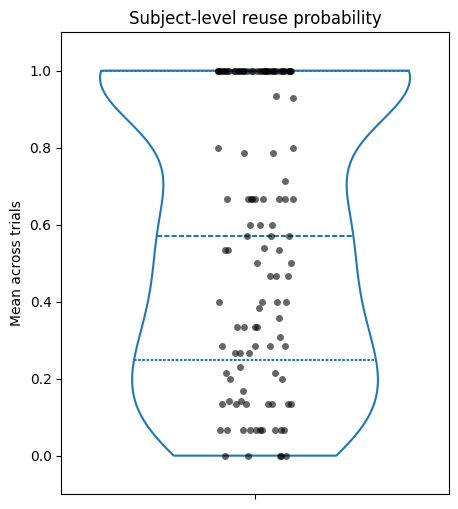

[Plot 1] P(reuse solution): mean = 0.5785, SEM = 0.0335, n_subjects = 119
[Plot 1] %subjs who always reuse: prop = 0.3361, n_subjects_tot = 119
[Plot 2] Logistic regression coef = 0.0009, intercept = -0.1588
[Plot 2] P(choose better cached sol | reuse cached sol): mean = 0.7264, SEM = 0.0230, n_subjects = 114;
 T-test t=9.837906902143219, p= 7.192250115506111e-17, Wilcoxon p=1.0466757875772125e-12, Cohen's d=0.9214044020208954


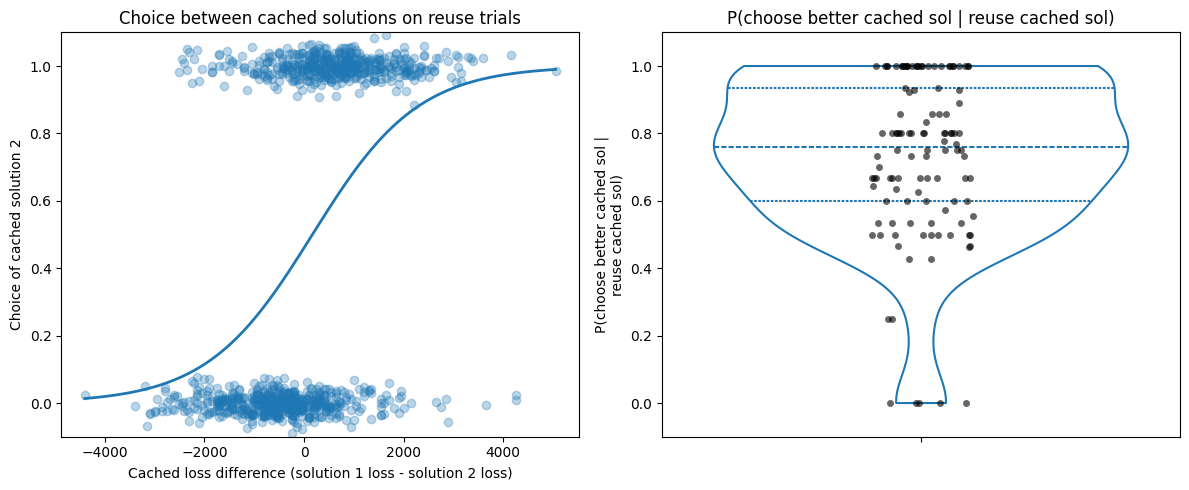

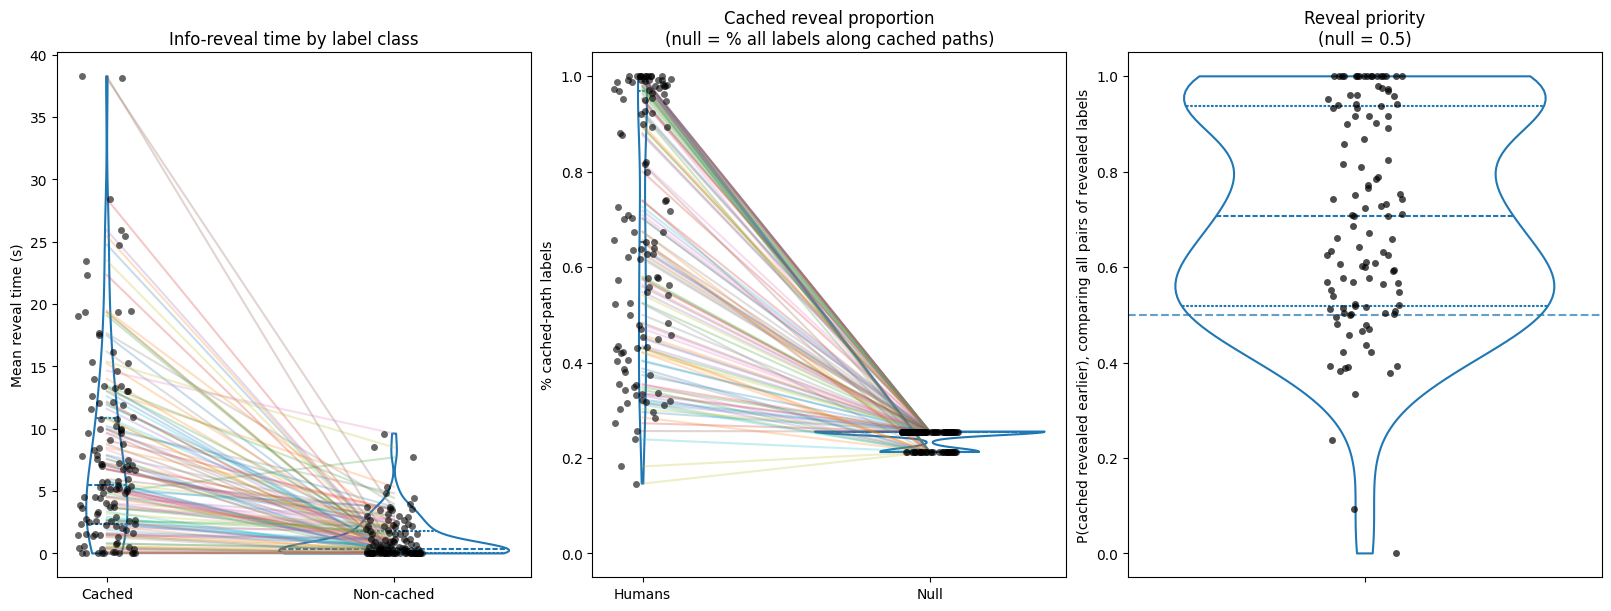

[Plot 3] Paired t-test, cached vs non-cached reveal time: cached mean = 7.8295, noncached mean = 1.1877, mean diff = 6.6418, t = 9.5046, p = 2.99043e-16, dz = 0.8713, n_subjects = 119 
wilcoxon = 46.0000, p = 9.50676e-20
[Plot 3] Paired t-test, subject-mean cached reveal proportion vs %cached-path labels among all labels: mean = 0.6744, null = 0.2425, mean diff = 0.4319, t = 17.2166, p = 3.01528e-33, dz = 1.6196, n_subjects = 113 
wilcoxon = 13.0000, p = 3.95737e-20
[Plot 3] One-sample t-test, cached priority vs 0.5: mean = 0.7032, mean diff from 0.5 = 0.2032, t = 9.4564, p = 5.94455e-16, dz = 0.8896, n_subjects = 113 
wilcoxon = 680.5000, p = 5.44854e-13


/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81124/2537709615.py:1289: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby(["subject_idx", "reuse_group"], as_index=False)[
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81124/2537709615.py:1332: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  subj.pivot_table(
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81124/2537709615.py:1332: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  subj.piv

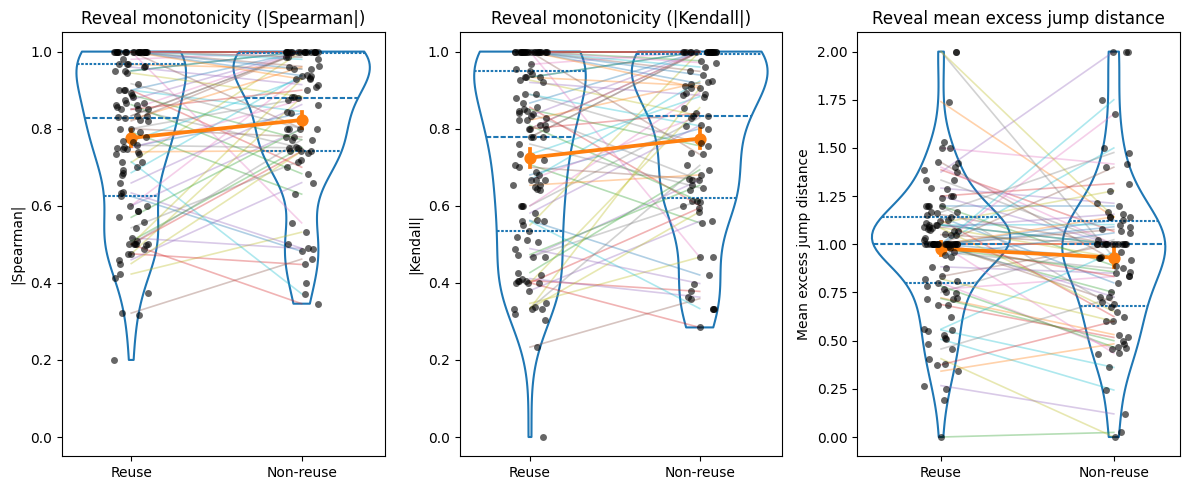

/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81124/2537709615.py:1146: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = subj.pivot_table(index="subject_idx", columns="reuse_group", values=value_col)
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81124/2537709615.py:1146: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = subj.pivot_table(index="subject_idx", columns="reuse_group", values=value_col)
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81124/2537709615.py:1146: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False t


Submitted-path reveal order metrics:
                 metric mean_reuse mean_nonreuse paired_t paired_p paired_dz wilcoxon_w wilcoxon_p  n_pairs
      Reveal |Spearman|      0.776         0.822   -2.102  0.03931    -0.255    643.500    0.04563       68
       Reveal |Kendall|      0.725         0.774   -2.107  0.03884    -0.256    602.000    0.03267       68
Reveal mean excess jump      0.978         0.931    2.159   0.0344     0.262    638.500     0.0178       68


In [8]:

from __future__ import annotations

import ast
import json
from itertools import combinations
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    from sklearn.linear_model import LogisticRegression
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

fill=False
inner="quart"

# =========================
# Parsing helpers
# =========================


def cohens_dz_from_diff(diff):
    """Cohen's dz for paired-sample or one-sample t-tests."""
    diff = pd.Series(diff).dropna()
    if len(diff) < 2:
        return np.nan
    return diff.mean() / diff.std(ddof=1)

def parse_maybe_json(x: Any) -> Any:
    if pd.isna(x):
        return None
    if isinstance(x, (dict, list, tuple, int, float, bool)):
        return x
    if not isinstance(x, str):
        return x
    s = x.strip()
    if s == "":
        return None
    try:
        return json.loads(s)
    except Exception:
        pass
    try:
        return ast.literal_eval(s)
    except Exception:
        return s


def coerce_bool(x: Any) -> Any:
    if pd.isna(x):
        return np.nan
    if isinstance(x, bool):
        return x
    if isinstance(x, (int, np.integer)):
        return bool(x)
    if isinstance(x, float):
        if np.isnan(x):
            return np.nan
        return bool(x)
    s = str(x).strip().lower()
    if s in {"true", "t", "1", "yes", "y"}:
        return True
    if s in {"false", "f", "0", "no", "n"}:
        return False
    return np.nan


def parse_info_reveal_seconds(x: Any) -> Dict[str, Dict[str, float]]:
    parsed = parse_maybe_json(x)
    if parsed is None:
        return {"nodes": {}, "edges": {}}
    nodes = parsed.get("nodes", {}) if isinstance(parsed, dict) else {}
    edges = parsed.get("edges", {}) if isinstance(parsed, dict) else {}
    nodes = {str(k): float(v) for k, v in nodes.items()}
    edges = {str(k): float(v) for k, v in edges.items()}
    return {"nodes": nodes, "edges": edges}


def extract_first_reveal_order_from_event_log(event_log: Any) -> Dict[str, Dict[str, float]]:
    parsed = parse_maybe_json(event_log)
    if not isinstance(parsed, list):
        return {"nodes": {}, "edges": {}}

    node_order = {}
    edge_order = {}
    counter = 1

    for ev in parsed:
        if not isinstance(ev, dict):
            continue
        if ev.get("type") != "label_shown":
            continue

        kind = ev.get("kind")
        if kind == "node":
            node_id = ev.get("node_id")
            if node_id is not None and node_id not in node_order:
                node_order[str(node_id)] = counter
                counter += 1
        elif kind == "edge":
            edge_id = ev.get("edge_id")
            if edge_id is not None and edge_id not in edge_order:
                edge_order[str(edge_id)] = counter
                counter += 1

    return {"nodes": node_order, "edges": edge_order}


def build_reveal_boolean_dict(info_reveal_seconds: Dict[str, Dict[str, float]]) -> Dict[str, Dict[str, bool]]:
    return {
        "nodes": {k: (v > 0) for k, v in info_reveal_seconds.get("nodes", {}).items()},
        "edges": {k: (v > 0) for k, v in info_reveal_seconds.get("edges", {}).items()},
    }


def build_reveal_order_full_dict(
    info_reveal_seconds: Dict[str, Dict[str, float]],
    first_order_partial: Dict[str, Dict[str, float]],
) -> Dict[str, Dict[str, float]]:
    out = {"nodes": {}, "edges": {}}
    all_nodes = info_reveal_seconds.get("nodes", {})
    all_edges = info_reveal_seconds.get("edges", {})
    partial_nodes = first_order_partial.get("nodes", {})
    partial_edges = first_order_partial.get("edges", {})

    for k in all_nodes:
        out["nodes"][k] = partial_nodes.get(k, np.nan)
    for k in all_edges:
        out["edges"][k] = partial_edges.get(k, np.nan)
    return out


def choose_cached_solution_with_lower_loss(
    submitted_path: Any,
    cached_solution_1: Any,
    cached_solution_2: Any,
    cached_solution_1_loss: Any,
    cached_solution_2_loss: Any,
) -> Any:
    if pd.isna(submitted_path):
        return np.nan
    chose_1 = submitted_path == cached_solution_1
    chose_2 = submitted_path == cached_solution_2
    if not (chose_1 or chose_2):
        return np.nan
    if pd.isna(cached_solution_1_loss) or pd.isna(cached_solution_2_loss):
        return np.nan
    if cached_solution_1_loss == cached_solution_2_loss:
        return np.nan
    lower_is_1 = cached_solution_1_loss < cached_solution_2_loss
    if chose_1:
        return int(lower_is_1)
    if chose_2:
        return int(not lower_is_1)
    return np.nan

# =========================
# Stats helpers
# =========================

def mean_sem(x: pd.Series) -> Tuple[float, float]:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return np.nan, np.nan
    m = x.mean()
    sem = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
    return m, sem


def subject_jitter(n: int, scale: float = 0.05) -> np.ndarray:
    if n <= 1:
        return np.array([0.0])
    rng = np.random.default_rng(0)
    return rng.normal(0, scale, size=n)


# =========================
# Plot 1
# =========================

def plot_p_reuse(test_df: pd.DataFrame, outdir: Path):
    subj = test_df.groupby(["subject_idx"], as_index=False)["submitted_equals_any_cached_solution"].mean()
    m, sem = mean_sem(subj["submitted_equals_any_cached_solution"])
    count = np.mean(subj["submitted_equals_any_cached_solution"]==1)

    fig, ax = plt.subplots(figsize=(5, 6))

    sns.violinplot(
        y=subj["submitted_equals_any_cached_solution"],
        inner=inner,
        fill=fill,
        cut=0,
        ax=ax
    )

    sns.stripplot(
        y=subj["submitted_equals_any_cached_solution"],
        color="black",
        alpha=0.6,
        jitter=0.1,
        ax=ax
    )

    ax.set_ylim([-0.1,1.1])
    ax.set_ylabel("Mean across trials")
    ax.set_title("Subject-level reuse probability")
    #fig.savefig(outdir / "plot1_p_reuse.png", dpi=200)
    plt.show()

    print(f"[Plot 1] P(reuse solution): mean = {m:.4f}, SEM = {sem:.4f}, n_subjects = {len(subj)}")
    print(f"[Plot 1] %subjs who always reuse: prop = {count:.4f}, n_subjects_tot = {len(subj)}")


# =========================
# Plot 2
# =========================

def plot_logistic_cached_choice(test_df: pd.DataFrame, outdir: Path):
    df = test_df.loc[test_df["submitted_equals_any_cached_solution"] == True].copy()
    df = df.loc[
        df["submitted_equals_cached_solution_1"].notna()
        & df["submitted_equals_cached_solution_2"].notna()
        & df["cached_solution_1_loss"].notna()
        & df["cached_solution_2_loss"].notna()
    ].copy()

    # x > 0 means solution 2 is better than solution 1
    df["x_lossdiff_sol2_minus_sol1_benefit"] = df["cached_solution_1_loss"] - df["cached_solution_2_loss"]
    df["y_choose_sol2"] = df["submitted_equals_cached_solution_2"].astype(int)

    fig, ax = plt.subplots(1,2,figsize=(12, 5))
    x = df["x_lossdiff_sol2_minus_sol1_benefit"].to_numpy()
    y = df["y_choose_sol2"].to_numpy()

    y_scatter = y + np.random.default_rng(0).normal(0, 0.03, size=len(y))
    ax[0].scatter(x, y_scatter, alpha=0.3)

    if len(np.unique(y)) > 1 and len(df) >= 5:
        if SKLEARN_AVAILABLE:
            model = LogisticRegression()
            model.fit(x.reshape(-1, 1), y)
            xgrid = np.linspace(np.min(x), np.max(x), 300)
            p = model.predict_proba(xgrid.reshape(-1, 1))[:, 1]
            ax[0].plot(xgrid, p, linewidth=2)
            print(f"[Plot 2] Logistic regression coef = {model.coef_[0,0]:.4f}, intercept = {model.intercept_[0]:.4f}")
        else:
            # fallback: binned means
            bins = np.linspace(np.min(x), np.max(x), 8)
            df["bin"] = pd.cut(df["x_lossdiff_sol2_minus_sol1_benefit"], bins=bins, include_lowest=True)
            binned = df.groupby("bin", observed=False).agg(
                x_mean=("x_lossdiff_sol2_minus_sol1_benefit", "mean"),
                y_mean=("y_choose_sol2", "mean")
            ).dropna()
            ax[0].plot(binned["x_mean"], binned["y_mean"], linewidth=2)
            print("[Plot 2] sklearn unavailable; plotted binned mean choice instead of fitted logistic curve.")

    ax[0].set_xlabel("Cached loss difference (solution 1 loss - solution 2 loss)")
    ax[0].set_ylabel("Choice of cached solution 2")
    ax[0].set_title("Choice between cached solutions on reuse trials")
    ax[0].set_ylim(-0.1, 1.1)
    
    df_subjmean = df.groupby(["subject_idx"], as_index=False)["chose_lower_loss_cached_solution"].mean()
    m, sem = mean_sem(df_subjmean["chose_lower_loss_cached_solution"])
    sns.violinplot(
        data = df_subjmean,
        y="chose_lower_loss_cached_solution",
        inner=inner,
        fill=fill,
        cut=0,
        ax=ax[1],
    )

    sns.stripplot(
        data = df_subjmean,
        y="chose_lower_loss_cached_solution",
        color="black",
        alpha=0.6,
        jitter=0.1,
        ax=ax[1]
    )

    ax[1].set_ylabel("P(choose better cached sol |\nreuse cached sol)")
    ax[1].set_title("P(choose better cached sol | reuse cached sol)")
    ax[1].set_ylim([-0.1,1.1])

    fig.tight_layout()
    #fig.savefig(outdir / "plot2_logistic_cached_choice.png", dpi=200)
    
    t_val, t_pval = scipy.stats.ttest_1samp(df_subjmean["chose_lower_loss_cached_solution"], popmean=0.5)
    _, w_pval = wilcoxon(df_subjmean["chose_lower_loss_cached_solution"] - 0.5)
    
    # 2. Calculate Cohen's d
    cohens_d = cohens_dz_from_diff(df_subjmean["chose_lower_loss_cached_solution"]-0.5)

    #plt.close(fig)
    print(f"[Plot 2] P(choose better cached sol | reuse cached sol): mean = {m:.4f}, SEM = {sem:.4f}, n_subjects = {len(df_subjmean)};\n T-test t={t_val}, p= {t_pval}, Wilcoxon p={w_pval}, Cohen's d={cohens_d}")
    # print(df_subjmean[df_subjmean['subject_idx'].isin({46, 47, 49, 51, 67, 72})])

# =========================
# Plot 3
# =========================

def compute_trial_cached_vs_noncached_reveal_means(row: pd.Series) -> Tuple[float, float, float, float]:
    '''Compute the 1) mean reveal time and 2) num_revealed for cached-path labels and non-cached path labels.
        Also return the total number of cached-path labels and non-cached path labels (which is dependent on whether the two cached paths share an edge)
    '''
    info_secs = row["info_reveal_seconds"]
    cached_labels = union_cached_label_set(row["cached_solution_1"], row["cached_solution_2"])

    cached_vals = []
    noncached_vals = []

    cached_counts = 0
    noncached_counts = 0
    
    cached_total_counts = 0
    noncached_total_counts = 0

    cached_node_set = set(cached_labels["nodes"])
    cached_edge_set = {canonicalize_edge_label(e) for e in cached_labels["edges"]}

    for node, sec in info_secs.get("nodes", {}).items():
        if node in cached_node_set:
            cached_vals.append(sec)
            cached_total_counts += 1
            if(sec>0):
                cached_counts += 1
        else:
            noncached_vals.append(sec)
            noncached_total_counts += 1
            if(sec>0):
                noncached_counts += 1

    for edge, sec in info_secs.get("edges", {}).items():
        edge = canonicalize_edge_label(edge)
        if edge in cached_edge_set:
            cached_vals.append(sec)
            cached_total_counts += 1
            if(sec>0):
                cached_counts += 1
        else:
            noncached_vals.append(sec)
            noncached_total_counts += 1
            if(sec>0):
                noncached_counts += 1
    cached_mean = np.mean(cached_vals) if len(cached_vals) else np.nan
    noncached_mean = np.mean(noncached_vals) if len(noncached_vals) else np.nan
    return cached_mean, noncached_mean, cached_counts, noncached_counts, cached_total_counts, noncached_total_counts



def compute_trial_cached_priority_score(row: pd.Series) -> float:
    """
    Returns a value in [0, 1]:
    - 1 = cached always revealed before noncached
    - 0 = noncached always before cached
    - 0.5 = no ordering preference

    Handles edge cases:
    - only cached → 1
    - only noncached → 0
    """
    order_dict = row["info_first_reveal_order"]
    cached_labels = union_cached_label_set(
        row["cached_solution_1"], row["cached_solution_2"]
    )
    if not isinstance(order_dict, dict):
        return np.nan

    cached_node_set = set(cached_labels["nodes"])
    cached_edge_set = {canonicalize_edge_label(e) for e in cached_labels["edges"]}

    cached_orders = []
    noncached_orders = []

    # nodes
    for node, ordv in order_dict.get("nodes", {}).items():
        if pd.notna(ordv):
            if node in cached_node_set:
                cached_orders.append(ordv)
            else:
                noncached_orders.append(ordv)

    # edges
    for edge, ordv in order_dict.get("edges", {}).items():
        if pd.notna(ordv):
            edge = canonicalize_edge_label(edge)
            if edge in cached_edge_set:
                cached_orders.append(ordv)
            else:
                noncached_orders.append(ordv)

    # edge cases
    if len(cached_orders) > 0 and len(noncached_orders) == 0:
        return 1.0
    if len(cached_orders) == 0 and len(noncached_orders) > 0:
        return 0.0
    if len(cached_orders) == 0 and len(noncached_orders) == 0:
        return np.nan

    # pairwise comparisons
    total = 0
    wins = 0

    for c in cached_orders:
        for n in noncached_orders:
            total += 1
            if c < n:
                wins += 1
            elif c == n:
                wins += 0.5

    return wins / total if total > 0 else np.nan

    
def plot_cached_vs_noncached_reveal_time(test_df: pd.DataFrame, outdir: Path):
    tmp = test_df.copy()

    tmp[[
        "cached_part_reveal_mean",
        "noncached_part_reveal_mean",
        "cached_part_reveal_count",
        "noncached_part_reveal_count",
        "cached_part_ntotlabels",
        "noncached_part_ntotlabels"
    ]] = tmp.apply(
        lambda r: pd.Series(compute_trial_cached_vs_noncached_reveal_means(r)),
        axis=1
    )
    tmp["prop_cached_part_labels"] = tmp["cached_part_ntotlabels"] / (tmp["cached_part_ntotlabels"] + tmp["noncached_part_ntotlabels"])

    
    tmp["cached_priority_score"] = tmp.apply(
        compute_trial_cached_priority_score,
        axis=1
    )
    subj_priority = tmp.groupby(["subject_idx"], as_index=False).agg(
        cached_priority_score=("cached_priority_score", "mean")
    )

    # subject-level cached reveal proportion
    denom = tmp["cached_part_reveal_count"] + tmp["noncached_part_reveal_count"]
    tmp["cached_part_reveal_prop"] = np.where(
        denom > 0,
        tmp["cached_part_reveal_count"] / denom,
        np.nan
    )

    # subject-level averages
    subj = tmp.groupby(["subject_idx"], as_index=False).agg(
        cached_part_reveal_mean=("cached_part_reveal_mean", "mean"),
        noncached_part_reveal_mean=("noncached_part_reveal_mean", "mean"),
        cached_part_reveal_prop=("cached_part_reveal_prop", "mean"),
        cached_part_labels_prop=("prop_cached_part_labels", "mean"),
    )

    # ---------------- subplot 1 test: cached vs non-cached reveal time ----------------
    paired = subj.dropna(subset=["cached_part_reveal_mean", "noncached_part_reveal_mean"]).copy()
    
    t_res = stats.ttest_rel(
        paired["cached_part_reveal_mean"],
        paired["noncached_part_reveal_mean"],
        nan_policy="omit"
    )
    
    wilcoxon_res = stats.wilcoxon(
        paired["cached_part_reveal_mean"],
        paired["noncached_part_reveal_mean"],
        nan_policy="omit"
    )
    
    reveal_time_diff = (
        paired["cached_part_reveal_mean"]
        - paired["noncached_part_reveal_mean"]
    )
    reveal_time_dz = cohens_dz_from_diff(reveal_time_diff)
    plot_df = paired.melt(
        id_vars=["subject_idx"],
        value_vars=["cached_part_reveal_mean", "noncached_part_reveal_mean"],
        var_name="label_type",
        value_name="reveal_time"
    )
    
    plot_df["label_type"] = plot_df["label_type"].map({
        "cached_part_reveal_mean": "Cached",
        "noncached_part_reveal_mean": "Non-cached"
    })

    # ---------------- subplot 2 test: cached reveal proportion vs null ----------------
    subj_prop = subj.dropna(subset=["cached_part_reveal_prop", "cached_part_labels_prop"]).copy()
    
    prop_t_res = stats.ttest_rel(
        subj_prop["cached_part_reveal_prop"],
        subj_prop["cached_part_labels_prop"],
        nan_policy="omit"
    )
    
    prop_wilcoxon_res = stats.wilcoxon(
        subj_prop["cached_part_reveal_prop"],
        subj_prop["cached_part_labels_prop"],
        nan_policy="omit"
    )
    
    prop_diff = (
        subj_prop["cached_part_reveal_prop"]
        - subj_prop["cached_part_labels_prop"]
    )
    prop_dz = cohens_dz_from_diff(prop_diff)

    # ---------------- subplot 3 test: cached vs non-cached mean reveal order ----------------
    priority_scores = subj_priority["cached_priority_score"].dropna()
    
    priority_t_res = stats.ttest_1samp(
        priority_scores,
        popmean=0.5
    )
    
    priority_wilcoxon_res = stats.wilcoxon(
        priority_scores - 0.5
    )
    priority_diff = priority_scores - 0.5
    priority_dz = cohens_dz_from_diff(priority_diff)

    # figure with 3 panels
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

    # ---------------- subplot 1 ----------------
    ax = axes[0]

    sns.violinplot(
        data=plot_df,
        x="label_type",
        y="reveal_time",
        inner=inner,
        fill=fill,
        cut=0,
        ax=ax
    )

    sns.stripplot(
        data=plot_df,
        x="label_type",
        y="reveal_time",
        color="black",
        alpha=0.6,
        jitter=0.1,
        ax=ax
    )

    for _, row in paired.iterrows():
        ax.plot(
            [0, 1],
            [row["cached_part_reveal_mean"], row["noncached_part_reveal_mean"]],
            alpha=0.25
        )

    ax.set_ylabel("Mean reveal time (s)")
    ax.set_xlabel("")
    ax.set_title("Info-reveal time by label class")

    # ---------------- subplot 2 ----------------
    ax2 = axes[1]

    # paired has one row per subject / pair

    prop_pair_df = subj_prop[[
        "cached_part_reveal_prop",
        "cached_part_labels_prop"
    ]].copy()
    
    long_df = prop_pair_df.melt(
        var_name="condition",
        value_name="prop"
    )
    
    long_df["condition"] = long_df["condition"].map({
        "cached_part_reveal_prop": "Humans",
        "cached_part_labels_prop": "Null"
    })

    sns.violinplot(
        data=long_df,
        x="condition",
        y="prop",
        inner=inner,
        fill=fill,
        cut=0,
        ax=ax2
    )
    
    sns.stripplot(
        data=long_df,
        x="condition",
        y="prop",
        color="black",
        alpha=0.6,
        jitter=0.1,
        ax=ax2
    )
    for _, row in subj_prop.iterrows():
        ax2.plot(
            [0, 1],
            [row["cached_part_reveal_prop"], row["cached_part_labels_prop"]],
            alpha=0.25
        )
    
    ax2.set_ylabel("% cached-path labels")
    ax2.set_xlabel("")
    ax2.set_title("Cached reveal proportion\n(null = % all labels along cached paths)")
    ax2.set_ylim(-0.05, 1.05)
    # ---------------- subplot 3 ----------------
    ax3 = axes[2]

    sns.violinplot(
        data=subj_priority,
        y="cached_priority_score",
        inner=inner,
        fill=fill,
        cut=0,
        ax=ax3
    )

    sns.stripplot(
        data=subj_priority,
        y="cached_priority_score",
        color="black",
        alpha=0.7,
        jitter=0.08,
        ax=ax3
    )

    ax3.axhline(0.5, linestyle="--", alpha=0.7)

    ax3.set_ylabel("P(cached revealed earlier), comparing all pairs of revealed labels")
    ax3.set_xlabel("")
    ax3.set_title("Reveal priority\n(null = 0.5)")
    ax3.set_ylim(0-0.05, 1+0.05)


    #fig.savefig(outdir / "plot3_info_reveal_time.png", dpi=200)
    plt.show()

    print(
        "[Plot 3] Paired t-test, cached vs non-cached reveal time: "
        f"cached mean = {paired['cached_part_reveal_mean'].mean():.4f}, "
        f"noncached mean = {paired['noncached_part_reveal_mean'].mean():.4f}, "
        f"mean diff = {reveal_time_diff.mean():.4f}, "
        f"t = {t_res.statistic:.4f}, "
        f"p = {t_res.pvalue:.6g}, "
        f"dz = {reveal_time_dz:.4f}, "
        f"n_subjects = {len(paired)}",
        f"\nwilcoxon = {wilcoxon_res.statistic:.4f}, p = {wilcoxon_res.pvalue:.6g}"
    )

    print(
        "[Plot 3] Paired t-test, subject-mean cached reveal proportion vs %cached-path labels among all labels: "
        f"mean = {subj_prop['cached_part_reveal_prop'].mean():.4f}, "
        f"null = {subj_prop['cached_part_labels_prop'].mean():.4f}, "
        f"mean diff = {prop_diff.mean():.4f}, "
        f"t = {prop_t_res.statistic:.4f}, "
        f"p = {prop_t_res.pvalue:.6g}, "
        f"dz = {prop_dz:.4f}, "
        f"n_subjects = {len(subj_prop)}",
        f"\nwilcoxon = {prop_wilcoxon_res.statistic:.4f}, p = {prop_wilcoxon_res.pvalue:.6g}"
    )

    print(
        "[Plot 3] One-sample t-test, cached priority vs 0.5: "
        f"mean = {priority_scores.mean():.4f}, "
        f"mean diff from 0.5 = {priority_diff.mean():.4f}, "
        f"t = {priority_t_res.statistic:.4f}, "
        f"p = {priority_t_res.pvalue:.6g}, "
        f"dz = {priority_dz:.4f}, "
        f"n_subjects = {len(priority_scores)}",
        f"\nwilcoxon = {priority_wilcoxon_res.statistic:.4f}, p = {priority_wilcoxon_res.pvalue:.6g}"
    )

        
# =========================
# Plot 5
# =========================
import numpy as np
import pandas as pd

def compute_trial_submitted_path_reveal_count(row: pd.Series) -> float:
    """
    Count the number of revealed info labels that lie along the final submitted path.

    This uses the same definition as the reveal-order metrics:
    - submitted path labels are obtained from row["submitted_path_string"]
    - revealed labels are those with non-NaN order values in row["info_first_reveal_order"]
    - both nodes and edges are included
    """
    observed_sorted = _extract_observed_submitted_path_sequence(
        row=row,
        order_col="info_first_reveal_order",
        include_nodes=True,
    )

    if len(observed_sorted) == 0:
        return 0.0

    return float(len(observed_sorted))


def compute_trial_submitted_path_total_label_count(row: pd.Series) -> float:
    """
    Count all possible info labels along the submitted path,
    regardless of whether they were revealed.
    Includes both nodes and edges.
    """
    expected_seq = path_to_expected_label_sequence(row["submitted_path_string"])

    if len(expected_seq) == 0:
        return np.nan

    return float(len(expected_seq))


def add_submitted_path_reveal_count_cols(test_df: pd.DataFrame) -> pd.DataFrame:
    """
    Add trial-level columns:
    - submitted_path_reveal_count:
        number of revealed labels along the final submitted path
    - submitted_path_total_label_count:
        total number of labels along the final submitted path
    - submitted_path_reveal_prop:
        proportion of submitted-path labels revealed
    """
    tmp = test_df.copy()

    tmp["submitted_path_reveal_count"] = tmp.apply(
        compute_trial_submitted_path_reveal_count,
        axis=1
    )

    tmp["submitted_path_total_label_count"] = tmp.apply(
        compute_trial_submitted_path_total_label_count,
        axis=1
    )

    tmp["submitted_path_reveal_prop"] = (
        tmp["submitted_path_reveal_count"]
        / tmp["submitted_path_total_label_count"]
    )

    return tmp



def _compute_path_local_continuity_label(
    order_dict,
    expected_seq,
    distance_thres: int = 3,
    require_monotonic: bool = False,
) -> float:
    """
    Generic helper.

    Parameters
    ----------
    order_dict : dict
        Nested order dictionary, e.g. row["last_select_order"] or row["info_first_reveal_order"].
    expected_seq : list of (kind, label)
        Expected submitted-path sequence in path order.
        For selection, this should usually contain only edges.
        For reveal, this can contain both edges and nodes.
    distance_thres : int
        Maximum allowed absolute jump in expected-sequence index between two
        consecutively observed labels.

        Examples:
        - distance_thres=3 is the looser "nonlocal jump" definition:
          only larger jumps count as violations.
        - distance_thres=2 is stricter for reveal sequences:
          this penalizes skipping over an intermediate path label.

    require_monotonic : bool
        If False:
            Only local continuity matters. Small backtracking is allowed.
        If True:
            In addition to local continuity, the sequence must be globally
            monotonic (either mostly forward or mostly backward, with no
            sign reversals among nonzero steps).

    Returns
    -------
    float
        1.0 if sequence is consistent with the chosen criterion,
        0.0 if it violates it,
        np.nan if fewer than 2 expected path labels were actually observed.
    """

    if order_dict is None or len(expected_seq) == 0:
        return np.nan

    # Keep only submitted-path labels that were actually observed,
    # and assign each its expected position along the submitted path.
    observed = []
    for idx, (kind, label) in enumerate(expected_seq):
        order_val = get_order_val(order_dict, kind, label)
        if pd.notna(order_val):
            observed.append((kind, label, float(order_val), idx))

    if len(observed) < 2:
        return np.nan

    # Sort by actual observed order
    observed_sorted = sorted(observed, key=lambda x: x[2])

    # Sequence of expected-path indices in actual observed order
    expected_idx_seq = [idx for (_, _, _, idx) in observed_sorted]

    # Consecutive path-index differences
    diffs = [
        expected_idx_seq[i + 1] - expected_idx_seq[i]
        for i in range(len(expected_idx_seq) - 1)
    ]

    # 1) Local continuity criterion: no jump larger than threshold
    if any(abs(d) > distance_thres for d in diffs):
        return 0.0

    # 2) Optional monotonicity criterion
    if require_monotonic:
        nonzero_diffs = [d for d in diffs if d != 0]
        if len(nonzero_diffs) >= 2:
            signs = [np.sign(d) for d in nonzero_diffs]
            if len(set(signs)) > 1:
                return 0.0

    return 1.0


def compute_trial_submitted_path_select_agreement(
    row: pd.Series,
    distance_thres: int = 1,
    require_monotonic: bool = False,
) -> float:
    """
    Selection consistency based on local continuity along the submitted path.

    This version uses ONLY the submitted-path EDGES, because only edges can be selected.

    Parameters
    ----------
    row : pd.Series
        Must contain:
        - row["submitted_path_string"]
        - row["last_select_order"]

    distance_thres : int
        Maximum allowed jump in edge-position index between consecutive selected edges.

        Recommended:
        - distance_thres=1 : strict edge-by-edge local continuity
        - distance_thres=2 : allows skipping one edge position

    require_monotonic : bool
        If True, require that the selected-edge sequence be globally forward
        or globally backward as well as locally continuous.

    Returns
    -------
    float
        1.0 = consistent
        0.0 = violating
        np.nan = fewer than 2 submitted-path edges were selected
    """

    expected_seq_full = path_to_expected_label_sequence(row["submitted_path_string"])
    if len(expected_seq_full) == 0:
        return np.nan

    # Selection only concerns edges
    expected_seq_edges = [(kind, label) for (kind, label) in expected_seq_full if kind == "edge"]

    return _compute_path_local_continuity_label(
        order_dict=row["last_select_order"],
        expected_seq=expected_seq_edges,
        distance_thres=distance_thres,
        require_monotonic=require_monotonic,
    )


import numpy as np
import pandas as pd

try:
    from scipy.stats import kendalltau, spearmanr
except ImportError:
    kendalltau = None
    spearmanr = None


def _extract_observed_submitted_path_sequence(
    row: pd.Series,
    order_col: str,
    include_nodes: bool = True,
):
    """
    Internal helper.

    Returns the actually observed on-submitted-path labels in actual observed order,
    together with their indices in the canonical submitted-path sequence.

    Parameters
    ----------
    row : pd.Series
        Must contain row["submitted_path_string"] and row[order_col].
    order_col : str
        Column name holding the nested order dict, e.g.
        "info_first_reveal_order" or "last_select_order".
    include_nodes : bool
        If True, canonical sequence includes both edges and nodes.
        If False, canonical sequence includes only edges.

    Returns
    -------
    observed_sorted : list of tuples
        Each tuple is (kind, label, observed_order, expected_idx),
        sorted by observed_order.
    """
    expected_seq_full = path_to_expected_label_sequence(row["submitted_path_string"])
    if len(expected_seq_full) == 0:
        return []

    if include_nodes:
        expected_seq = expected_seq_full
    else:
        expected_seq = [(kind, label) for (kind, label) in expected_seq_full if kind == "edge"]

    order_dict = row[order_col]
    observed = []

    for expected_idx, (kind, label) in enumerate(expected_seq):
        order_val = get_order_val(order_dict, kind, label)
        if pd.notna(order_val):
            observed.append((kind, label, float(order_val), expected_idx))

    observed_sorted = sorted(observed, key=lambda x: x[2])
    return observed_sorted


def compute_trial_submitted_path_order_mean_excess_jump_distance(
    row: pd.Series,
    order_col: str = "info_first_reveal_order",
    include_nodes: bool = True,
    baseline_step: int = 1,
) -> float:
    """
    Mean excess jump distance for one trial.

    For the observed on-path sequence, let expected_idx_seq be the sequence of
    canonical submitted-path indices in actual observed order.

    For each consecutive transition:
        jump_excess = max(abs(diff) - baseline_step, 0)

    This returns the MEAN jump_excess across transitions.

    Interpretation
    --------------
    - 0.0 means perfectly local progression under the chosen baseline_step.
    - Larger values mean more nonlocal jumps.

    Parameters
    ----------
    row : pd.Series
    order_col : str
        Usually:
        - "info_first_reveal_order" for reveal labels
        - "last_select_order" for selected edges
    include_nodes : bool
        True for reveal labels, False for edge selection.
    baseline_step : int
        Default 1 means adjacent canonical labels incur no penalty.

    Returns
    -------
    float
        Mean excess jump distance, or np.nan if fewer than 2 on-path labels observed.
    """
    observed_sorted = _extract_observed_submitted_path_sequence(
        row=row,
        order_col=order_col,
        include_nodes=include_nodes,
    )

    if len(observed_sorted) < 2:
        return np.nan

    expected_idx_seq = [expected_idx for (_, _, _, expected_idx) in observed_sorted]
    diffs = np.diff(expected_idx_seq)

    jump_excess = np.maximum(np.abs(diffs) - baseline_step, 0)

    if len(jump_excess) == 0:
        return np.nan

    return float(np.mean(jump_excess))


def compute_trial_submitted_path_order_monotonicity(
    row: pd.Series,
    order_col: str = "info_first_reveal_order",
    include_nodes: bool = True,
    method: str = "spearman",
    absolute_value: bool = True,
) -> float:
    """
    Monotonicity/orderliness score for one trial using either Spearman rho
    or Kendall tau.

    We compare:
    - actual observed order positions: 0, 1, 2, ..., n-1
    - canonical submitted-path indices of those same observed labels

    A value near:
    - +1 means strong forward monotonicity
    - -1 means strong reverse monotonicity
    -  0 means weak / scrambled monotonicity

    If absolute_value=True, perfect reversal also becomes 1.0.

    Parameters
    ----------
    row : pd.Series
    order_col : str
        Usually:
        - "info_first_reveal_order" for reveal labels
        - "last_select_order" for selected edges
    include_nodes : bool
        True for reveal labels, False for edge selection.
    method : {"spearman", "kendall"}
        Which monotonicity statistic to use.
    absolute_value : bool
        If True, take abs(statistic), so both perfect forward and perfect reverse
        order count as maximally monotone.

    Returns
    -------
    float
        Monotonicity score, or np.nan if fewer than 2 on-path labels observed.
    """
    observed_sorted = _extract_observed_submitted_path_sequence(
        row=row,
        order_col=order_col,
        include_nodes=include_nodes,
    )

    if len(observed_sorted) < 2:
        return np.nan

    expected_idx_seq = np.array([expected_idx for (_, _, _, expected_idx) in observed_sorted], dtype=float)
    observed_positions = np.arange(len(expected_idx_seq), dtype=float)

    # print(observed_sorted, observed_positions, expected_idx_seq)

    method = method.lower()

    if method == "spearman":
        if spearmanr is None:
            raise ImportError("scipy is required for method='spearman'")
        stat = spearmanr(observed_positions, expected_idx_seq).statistic

    elif method == "kendall":
        if kendalltau is None:
            raise ImportError("scipy is required for method='kendall'")
        stat = kendalltau(observed_positions, expected_idx_seq).statistic

    else:
        raise ValueError("method must be either 'spearman' or 'kendall'")

    if pd.isna(stat):
        return np.nan

    if absolute_value:
        stat = abs(stat)

    return float(stat)


# ------------------------------------------------------------------
# Convenience wrappers
# ------------------------------------------------------------------

def compute_trial_submitted_path_reveal_mean_excess_jump_distance(row: pd.Series) -> float:
    """
    Reveal-order mean excess jump distance.
    Uses both edges and nodes along the submitted path.
    """
    return compute_trial_submitted_path_order_mean_excess_jump_distance(
        row=row,
        order_col="info_first_reveal_order",
        include_nodes=True,
        baseline_step=1,
    )


def compute_trial_submitted_path_reveal_monotonicity(
    row: pd.Series,
    method: str = "spearman",
    absolute_value: bool = True,
) -> float:
    """
    Reveal-order monotonicity using Spearman or Kendall.
    Uses both edges and nodes along the submitted path.
    """
    return compute_trial_submitted_path_order_monotonicity(
        row=row,
        order_col="info_first_reveal_order",
        include_nodes=True,
        method=method,
        absolute_value=absolute_value,
    )


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


def _run_group_tests(subj: pd.DataFrame, value_col: str, groups=("Reuse", "Non-reuse")) -> dict:
    """
    Run:
    - paired t-test (subjects with both groups)
    - Wilcoxon signed-rank test (subjects with both groups)
    - Welch two-sample t-test (all subjects)
    - Mann-Whitney U test (all subjects)

    on a subject-level summary column.
    """
    g1, g2 = groups

    # Wide for paired tests
    wide = subj.pivot_table(index="subject_idx", columns="reuse_group", values=value_col)
    pair = wide[[g1, g2]].dropna() if all(g in wide.columns for g in groups) else pd.DataFrame(columns=groups)

    # Long for unpaired tests
    x1 = subj.loc[subj["reuse_group"] == g1, value_col].dropna()
    x2 = subj.loc[subj["reuse_group"] == g2, value_col].dropna()

    out = {
        "metric": value_col,
        "paired_t": np.nan,
        "paired_p": np.nan,
        "paired_dz": np.nan,
        "wilcoxon_w": np.nan,
        "wilcoxon_p": np.nan,
        "n_pairs": len(pair),
        "mean_reuse": np.nan if len(x1) == 0 else float(np.mean(x1)),
        "mean_nonreuse": np.nan if len(x2) == 0 else float(np.mean(x2)),
    }

    if len(pair) >= 2:
        # Paired t-test
        res_p = stats.ttest_rel(pair[g1], pair[g2], nan_policy="omit")
        out["paired_t"] = float(res_p.statistic)
        out["paired_p"] = float(res_p.pvalue)
    
        # Cohen's dz: mean paired difference / SD paired difference
        diffs = pair[g1] - pair[g2]
        diffs = diffs.dropna()
        out["paired_dz"] = float(cohens_dz_from_diff(diffs))
    
        # Wilcoxon signed-rank
        if len(diffs) >= 1 and not np.allclose(diffs.to_numpy(), 0):
            try:
                res_wil = stats.wilcoxon(pair[g1], pair[g2])
                out["wilcoxon_w"] = float(res_wil.statistic)
                out["wilcoxon_p"] = float(res_wil.pvalue)
            except Exception:
                pass

    return out


def _pretty_test_table(results: list[dict], title: str):
    df = pd.DataFrame(results).copy()

    # cleaner metric names in printout
    metric_name_map = {
        "submitted_path_reveal_order_agreement": "Reveal agreement",
        "submitted_path_select_order_agreement": "Select agreement",
        "submitted_path_reveal_mean_excess_jump_distance": "Reveal mean excess jump",
        "submitted_path_select_mean_excess_jump_distance": "Select mean excess jump",
        "submitted_path_reveal_spearman_abs": "Reveal |Spearman|",
        "submitted_path_select_spearman_abs": "Select |Spearman|",
        "submitted_path_reveal_kendall_abs": "Reveal |Kendall|",
        "submitted_path_select_kendall_abs": "Select |Kendall|",
    }
    df["metric"] = df["metric"].map(metric_name_map).fillna(df["metric"])
    

    # reorder columns
    df = df[
        [
            "metric",
            "mean_reuse",
            "mean_nonreuse",
            "paired_t",
            "paired_p",
            "paired_dz",
            "wilcoxon_w",
            "wilcoxon_p",
            "n_pairs",
        ]
    ]

    # formatting
    df["mean_reuse"] = df["mean_reuse"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "nan")
    df["mean_nonreuse"] = df["mean_nonreuse"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "nan")

    df["paired_t"] = df["paired_t"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")
    df["paired_p"] = df["paired_p"].map(lambda x: f"{x:.4g}" if pd.notna(x) else "NA")
    df["paired_dz"] = df["paired_dz"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")

    df["wilcoxon_w"] = df["wilcoxon_w"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")
    df["wilcoxon_p"] = df["wilcoxon_p"].map(lambda x: f"{x:.4g}" if pd.notna(x) else "NA")

    print(f"\n{title}")
    print(df.to_string(index=False))



    

def plot_submitted_path_reveal_agreement(test_df: pd.DataFrame, outdir: Path):
    tmp = test_df.copy()

    tmp["submitted_path_reveal_count"] = tmp.apply(
        compute_trial_submitted_path_reveal_count,
        axis=1
    )

    tmp["submitted_path_total_label_count"] = tmp.apply(
        compute_trial_submitted_path_total_label_count,
        axis=1
    )

    tmp["submitted_path_reveal_prop"] = (
        tmp["submitted_path_reveal_count"]
        / tmp["submitted_path_total_label_count"]
    )

    tmp["is_reuse"] = tmp["submitted_equals_any_cached_solution"].astype(int)



    # --- reveal order metrics ---
    tmp["submitted_path_reveal_mean_excess_jump_distance"] = tmp.apply(
        compute_trial_submitted_path_reveal_mean_excess_jump_distance, axis=1
    )
    tmp["submitted_path_reveal_spearman_abs"] = tmp.apply(
        lambda row: compute_trial_submitted_path_reveal_monotonicity(
            row, method="spearman", absolute_value=True
        ),
        axis=1
    )
    tmp["submitted_path_reveal_kendall_abs"] = tmp.apply(
        lambda row: compute_trial_submitted_path_reveal_monotonicity(
            row, method="kendall", absolute_value=True
        ),
        axis=1
    )


    # --- grouping ---
    tmp["reuse_group"] = tmp["submitted_equals_any_cached_solution"].map(
        {True: "Reuse", False: "Non-reuse"}
    )
    tmp["reuse_group"] = pd.Categorical(
        tmp["reuse_group"], categories=["Reuse", "Non-reuse"], ordered=True
    )
    groups = ["Reuse", "Non-reuse"]

    # subject-level means
    subj = (
        tmp.groupby(["subject_idx", "reuse_group"], as_index=False)[
            [
                "submitted_path_reveal_spearman_abs",
                "submitted_path_reveal_kendall_abs",
                "submitted_path_reveal_mean_excess_jump_distance",
            ]
        ]
        .mean()
    )

    # --- plotting ---
    fig, ax = plt.subplots(1,3, figsize=(12,5))

    plot_specs = [
        ("submitted_path_reveal_spearman_abs", "Reveal monotonicity (|Spearman|)", "|Spearman|", (-0.05, 1.05)),
        ("submitted_path_reveal_kendall_abs", "Reveal monotonicity (|Kendall|)", "|Kendall|", (-0.05, 1.05)),
        ("submitted_path_reveal_mean_excess_jump_distance", "Reveal mean excess jump distance", "Mean excess jump distance", None),
    ]

    for i, (col, title, ylabel, ylim) in enumerate(plot_specs):

        sns.violinplot(
            data=subj,
            x="reuse_group",
            y=col,
            inner=inner,
            fill=fill,
            cut=0,
            ax=ax[i]
        )
        sns.stripplot(
            data=subj,
            x="reuse_group",
            y=col,
            color="black",
            alpha=0.6,
            jitter=0.1,
            ax=ax[i]
        )
        sns.pointplot(x="reuse_group", y=col, data=subj, estimator=np.mean, color="C1", errorbar="se", ax=ax[i])
        
        # --- connect paired subject points ---
        wide_for_lines = (
            subj.pivot_table(
                index="subject_idx",
                columns="reuse_group",
                values=col,
                aggfunc="mean"
            )
            .reindex(columns=groups)
            .dropna(subset=groups)
        )

        for _, row_wide in wide_for_lines.iterrows():
            ax[i].plot(
                [0, 1],
                [row_wide["Reuse"], row_wide["Non-reuse"]],
                alpha=0.35,
                linewidth=1.2,
                zorder=1,
            )


        ax[i].set_title(title)
        ax[i].set_ylabel(ylabel)
        ax[i].set_xlabel("")
        if ylim is not None:
            ax[i].set_ylim(ylim)

    plt.tight_layout()
    #fig.savefig(outdir / "plot5_info_reveal_select_order.png", dpi=200)
    plt.show()

    # --- tests ---
    test_cols_main = [
        "submitted_path_reveal_spearman_abs",
        "submitted_path_reveal_kendall_abs",
        "submitted_path_reveal_mean_excess_jump_distance",
    ]

    results_main = [_run_group_tests(subj, col, groups=groups) for col in test_cols_main]
    _pretty_test_table(results_main, title="Submitted-path reveal order metrics:")
    
    return tmp
    

    
# =========================
# Runner
# =========================

def make_all_visualizations(data_dir: str | Path, outdir: str | Path | None = None):
    data_dir = Path(data_dir)
    outdir = Path(outdir) if outdir is not None else data_dir / "analysis_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    plot_p_reuse(test_df, outdir)
    plot_logistic_cached_choice(test_df, outdir)
    plot_cached_vs_noncached_reveal_time(test_df, outdir)
    test_df_aug = plot_submitted_path_reveal_agreement(test_df, outdir)

    return test_df_aug



if __name__ == "__main__":
    # Example:
    test_df = make_all_visualizations(datapath)
    test_df.to_csv(os.path.join("data","exp3_data.csv"), index=False, header=True)


# Figures

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Change default font size
plt.rcParams['font.size'] = 10

|Spearman|: reuse=0.794, non-reuse=0.836, paired t=-2.102, p=0.03931, n=68
|Kendall|: reuse=0.743, non-reuse=0.791, paired t=-2.107, p=0.03884, n=68
E[jump distance]: reuse=0.999, non-reuse=0.914, paired t=2.159, p=0.0344, n=68


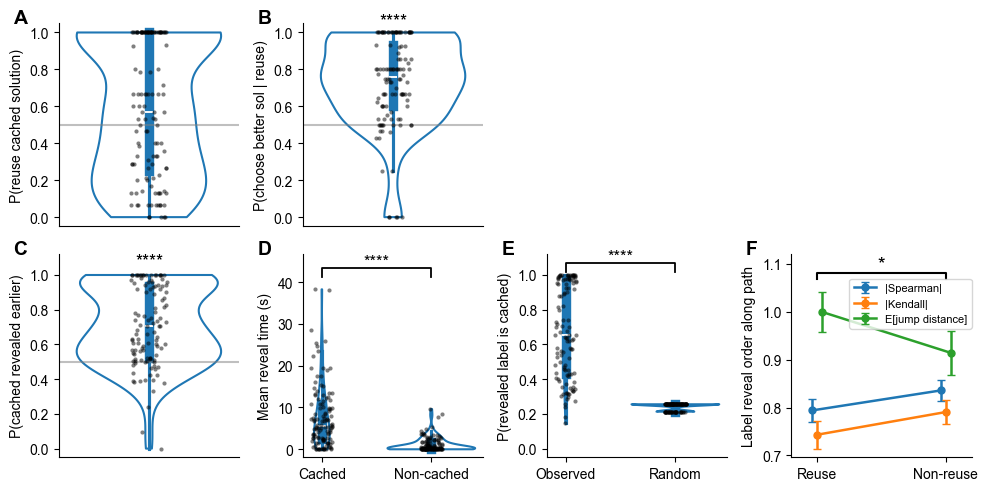

Saved poster figure to: exp3.pdf


In [10]:
inner = "box"#"quart"


def mean_sem_array(x):
    x = pd.Series(x).dropna()
    return x.mean(), x.std(ddof=1) / np.sqrt(len(x))

def plot_exp1c(test_df: pd.DataFrame, outdir: str | Path):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    fig = plt.figure(figsize=(10, 5))
    gs = fig.add_gridspec(2, 4)

    ax = [
        fig.add_subplot(gs[0, 0]),  # A
        fig.add_subplot(gs[0, 1]),  # B
        fig.add_subplot(gs[1, 0]),    # C reveal time
        fig.add_subplot(gs[1, 1]),    # D reveal proportion
        fig.add_subplot(gs[1, 2]),    # E reveal priority
        fig.add_subplot(gs[1, 3]),    # F order metrics
    ]

    def p_to_stars(p):
        if p < 0.0001:
            return "****"
        elif p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return "n.s."

    def add_bracket(a, x1, x2, y, text, height_frac=0.04):
        yrange = a.get_ylim()[1] - a.get_ylim()[0]
        h = yrange * height_frac
        a.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", lw=1.3)
        a.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=12)

    # panel labels
    for i_panel, a in enumerate(ax):
        a.text(
            -0.25, 1.07,
            "ABCDEF"[i_panel],
            transform=a.transAxes,
            fontsize=14,
            fontweight="bold",
            va="top",
            ha="left",
        )

    # ============================================================
    # A: P(reuse)
    # ============================================================
    subj_reuse = (
        test_df.groupby(["subject_idx"], as_index=False)
        ["submitted_equals_any_cached_solution"]
        .mean()
    )

    sns.violinplot(
        data=subj_reuse,
        y="submitted_equals_any_cached_solution",
        inner=inner,
        fill=False,
        cut=0,
        ax=ax[0],
    )
    sns.stripplot(
        data=subj_reuse,
        y="submitted_equals_any_cached_solution",
        color="black",
        alpha=0.5,
        jitter=0.10,
        size=3,
        ax=ax[0],
    )

    ax[0].axhline(0.5, linestyle="-", color="gray", alpha=0.5)
    ax[0].set_ylim(-0.05, 1.05)
    ax[0].set_xticks([])
    ax[0].set_ylabel("P(reuse cached solution)")

    # ============================================================
    # B: P(choose better sol | reuse)
    # ============================================================
    df_cached = test_df.loc[
        test_df["submitted_equals_any_cached_solution"] == True
    ].copy()

    df_cached = df_cached.loc[
        df_cached["chose_lower_loss_cached_solution"].notna()
    ].copy()

    subj_better = (
        df_cached.groupby("subject_idx", as_index=False)
        ["chose_lower_loss_cached_solution"]
        .mean()
    )

    sns.violinplot(
        data=subj_better,
        y="chose_lower_loss_cached_solution",
        inner=inner,
        fill=False,
        cut=0,
        ax=ax[1],
    )
    sns.stripplot(
        data=subj_better,
        y="chose_lower_loss_cached_solution",
        color="black",
        alpha=0.5,
        jitter=0.10,
        size=3,
        ax=ax[1],
    )

    ax[1].axhline(0.5, linestyle="-", color="gray", alpha=0.5)
    t_better = stats.ttest_1samp(
        subj_better["chose_lower_loss_cached_solution"].dropna(),
        popmean=0.5,
    )
    ax[1].text(
        0,
        1.01,
        p_to_stars(t_better.pvalue),
        ha="center",
        va="bottom",
        fontsize=13,
    )

    ax[1].set_ylim(-0.05, 1.05)
    ax[1].set_xticks([])
    ax[1].set_ylabel("P(choose better sol | reuse)")

    # ============================================================
    # Shared reveal metrics
    # ============================================================
    tmp = test_df.copy()

    tmp[[
        "cached_part_reveal_mean",
        "noncached_part_reveal_mean",
        "cached_part_reveal_count",
        "noncached_part_reveal_count",
        "cached_part_ntotlabels",
        "noncached_part_ntotlabels",
    ]] = tmp.apply(
        lambda r: pd.Series(compute_trial_cached_vs_noncached_reveal_means(r)),
        axis=1,
    )

    tmp["prop_cached_part_labels"] = (
        tmp["cached_part_ntotlabels"]
        / (tmp["cached_part_ntotlabels"] + tmp["noncached_part_ntotlabels"])
    )

    denom = tmp["cached_part_reveal_count"] + tmp["noncached_part_reveal_count"]
    tmp["cached_part_reveal_prop"] = np.where(
        denom > 0,
        tmp["cached_part_reveal_count"] / denom,
        np.nan,
    )

    tmp["cached_priority_score"] = tmp.apply(
        compute_trial_cached_priority_score,
        axis=1,
    )

    subj_reveal = (
        tmp.groupby(["subject_idx"], as_index=False)
        .agg(
            cached_part_reveal_mean=("cached_part_reveal_mean", "mean"),
            noncached_part_reveal_mean=("noncached_part_reveal_mean", "mean"),
            cached_part_reveal_prop=("cached_part_reveal_prop", "mean"),
            cached_part_labels_prop=("prop_cached_part_labels", "mean"),
            cached_priority_score=("cached_priority_score", "mean"),
        )
    )

    # ============================================================
    # C: reveal time
    # ============================================================
    paired_time = subj_reveal.dropna(
        subset=["cached_part_reveal_mean", "noncached_part_reveal_mean"]
    ).copy()

    time_long = paired_time.melt(
        id_vars=["subject_idx"],
        value_vars=["cached_part_reveal_mean", "noncached_part_reveal_mean"],
        var_name="label_type",
        value_name="value",
    )
    time_long["label_type"] = time_long["label_type"].map({
        "cached_part_reveal_mean": "Cached",
        "noncached_part_reveal_mean": "Non-cached",
    })

    sns.violinplot(data=time_long, x="label_type", y="value", inner=inner,
                   fill=False, cut=0, ax=ax[3])
    sns.stripplot(data=time_long, x="label_type", y="value", color="black",
                  alpha=0.5, jitter=0.10, size=3, ax=ax[3])

    t_time = stats.ttest_rel(
        paired_time["cached_part_reveal_mean"],
        paired_time["noncached_part_reveal_mean"],
    )
    ymax = time_long["value"].max()
    ax[3].set_ylim(top=ymax * 1.22)
    add_bracket(ax[3], 0, 1, ymax * 1.08, p_to_stars(t_time.pvalue))

    ax[3].set_xlabel("")
    ax[3].set_ylabel("Mean reveal time (s)")

    # ============================================================
    # D: reveal proportion
    # ============================================================
    paired_prop = subj_reveal.dropna(
        subset=["cached_part_reveal_prop", "cached_part_labels_prop"]
    ).copy()

    prop_long = paired_prop.melt(
        id_vars=["subject_idx"],
        value_vars=["cached_part_reveal_prop", "cached_part_labels_prop"],
        var_name="condition",
        value_name="value",
    )
    prop_long["condition"] = prop_long["condition"].map({
        "cached_part_reveal_prop": "Observed",
        "cached_part_labels_prop": "Random",
    })

    sns.violinplot(data=prop_long, x="condition", y="value", inner=inner,
                   fill=False, cut=0, ax=ax[4])
    sns.stripplot(data=prop_long, x="condition", y="value", color="black",
                  alpha=0.5, jitter=0.10, size=3, ax=ax[4])

    t_prop = stats.ttest_rel(
        paired_prop["cached_part_reveal_prop"],
        paired_prop["cached_part_labels_prop"],
    )
    ax[4].set_ylim(-0.05, 1.12)
    add_bracket(ax[4], 0, 1, 1.02, p_to_stars(t_prop.pvalue))

    ax[4].set_xlabel("")
    ax[4].set_ylabel("P(revealed label is cached)")

    # ============================================================
    # E: cached reveal priority
    # ============================================================
    priority_df = subj_reveal.dropna(subset=["cached_priority_score"]).copy()

    sns.violinplot(data=priority_df, y="cached_priority_score", inner=inner,
                   fill=False, cut=0, ax=ax[2])
    sns.stripplot(data=priority_df, y="cached_priority_score", color="black",
                  alpha=0.5, jitter=0.10, size=3, ax=ax[2])

    ax[2].axhline(0.5, linestyle="-", color="gray", alpha=0.5)
    t_priority = stats.ttest_1samp(
        priority_df["cached_priority_score"],
        popmean=0.5,
    )
    ax[2].text(
        0,
        1.03,
        p_to_stars(t_priority.pvalue),
        ha="center",
        va="bottom",
        fontsize=13,
    )

    ax[2].set_ylim(-0.05, 1.12)
    ax[2].set_xticks([])
    ax[2].set_ylabel("P(cached revealed earlier)")

    # ============================================================
    # F: order metrics
    # ============================================================
    tmp["submitted_path_reveal_mean_excess_jump_distance"] = tmp.apply(
        compute_trial_submitted_path_reveal_mean_excess_jump_distance,
        axis=1,
    )
    tmp["submitted_path_reveal_spearman_abs"] = tmp.apply(
        lambda row: compute_trial_submitted_path_reveal_monotonicity(
            row, method="spearman", absolute_value=True
        ),
        axis=1,
    )
    tmp["submitted_path_reveal_kendall_abs"] = tmp.apply(
        lambda row: compute_trial_submitted_path_reveal_monotonicity(
            row, method="kendall", absolute_value=True
        ),
        axis=1,
    )

    tmp["reuse_group"] = tmp["submitted_equals_any_cached_solution"].map({
        True: "Reuse",
        False: "Non-reuse",
    })

    subj_order = (
        tmp.groupby(["subject_idx", "reuse_group"], as_index=False)
        .agg(
            reveal_spearman_abs=("submitted_path_reveal_spearman_abs", "mean"),
            reveal_kendall_abs=("submitted_path_reveal_kendall_abs", "mean"),
            reveal_mean_jump=("submitted_path_reveal_mean_excess_jump_distance", "mean"),
        )
    )

    metric_specs = [
        ("reveal_spearman_abs", "|Spearman|"),
        ("reveal_kendall_abs", "|Kendall|"),
        ("reveal_mean_jump", "E[jump distance]"),
    ]

    x_base = np.array([0, 1])
    offsets = [-0.04, 0.00, 0.04]

    for i_metric, (offset, (col, label)) in enumerate(zip(offsets, metric_specs)):
        wide = (
            subj_order.pivot_table(
                index="subject_idx",
                columns="reuse_group",
                values=col,
                aggfunc="mean",
            )
            .reindex(columns=["Reuse", "Non-reuse"])
            .dropna()
        )

        means = wide[["Reuse", "Non-reuse"]].mean()
        sems = wide[["Reuse", "Non-reuse"]].sem()

        ax[5].errorbar(
            x_base + offset,
            means.to_numpy(),
            yerr=sems.to_numpy(),
            fmt="o-",
            capsize=3,
            linewidth=1.8,
            markersize=5,
            label=label,
        )

        # if len(wide) >= 2:
        #     t_res = stats.ttest_rel(wide["Reuse"], wide["Non-reuse"])
        #     print(
        #         f"{label}: reuse={means['Reuse']:.3f}, "
        #         f"non-reuse={means['Non-reuse']:.3f}, "
        #         f"paired t={t_res.statistic:.3f}, p={t_res.pvalue:.4g}, "
        #         f"n={len(wide)}"
        #     )

        if len(wide) >= 2:
            t_res = stats.ttest_rel(wide["Reuse"], wide["Non-reuse"])
            # significance bracket
            ymax = 1
            y_bracket = ymax * 1.08

            if(i_metric==0): # Only plot significance once; all three metric have the same level of significance
                ax[5].plot(
                    [0, 0, 1, 1],
                    [y_bracket * 0.99, y_bracket, y_bracket, y_bracket * 0.99],
                    color="black",
                    linewidth=1.5,
                )
                ax[5].text(
                    0.5,
                    y_bracket * 1,
                    "*",
                    ha="center",
                    va="bottom",
                    fontsize=14,
                )
            print(
                f"{label}: reuse={means['Reuse']:.3f}, "
                f"non-reuse={means['Non-reuse']:.3f}, "
                f"paired t={t_res.statistic:.3f}, p={t_res.pvalue:.4g}, "
                f"n={len(wide)}"
            )

    ax[5].set_xticks([0, 1])
    ax[5].set_xlim([-0.2, 1.2])
    ax[5].set_ylim(top=1.12)
    ax[5].set_xticklabels(["Reuse", "Non-reuse"])
    ax[5].set_ylabel("Label reveal order along path")
    ax[5].legend(
        loc="upper right",
        bbox_to_anchor=(1.0, 0.88),
        borderaxespad=0,
        fontsize=8,
        #frameon=False,
    )

    # ============================================================
    # final styling
    # ============================================================
    for a in ax:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    fig.tight_layout()
    #fig.savefig(os.path.join(figpath,"exp3_results.png"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(figpath,"exp3_results.pdf"), bbox_inches="tight")
    plt.show()

    print(f"Saved poster figure to: {'exp3_results.pdf'}")


plot_exp1c(test_df, datapath)